In [ ]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain_classic.tools import WikipediaQueryRun
from langchain_classic.utilities import WikipediaAPIWrapper
from langchain_classic.document_loaders import PyMuPDFLoader
from langchain_classic.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter

from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command

from langgraph_supervisor import create_supervisor
from langchain_classic.tools.retriever import create_retriever_tool
from langchain_groq import ChatGroq


In [5]:
def make_retriever_tool_from_text(file_path, tool_name, desc):
    loader = PyMuPDFLoader(file_path=file_path)
    docs = loader.load()
    
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=80)
    chunks = text_splitter.split_documents(docs)
    
    vectorstore = FAISS.from_documents(chunks, OpenAIEmbeddings())
    retriever = vectorstore.as_retriever()
    
    def tool_retriever():
        retriever_tool = create_retriever_tool(
            retriever,
            tool_name,
            desc
        )
    
        return retriever_tool
    
    retriever_tool = tool_retriever()
    return retriever_tool

In [ ]:
nilai_farhan_tool = make_retriever_tool_from_text(
    "pdf/farhan.pdf",
    "SikadFarhan",
    "Mencari informasi nilai untuk mahasiswa farhan dan IPK farhan atau hasil akhir perkuliahan farhan"
)

nilai_ratu_tool = make_retriever_tool_from_text(
    "pdf/ratu.pdf",
    "SikadRatu",
    "Mencari informasi nilai untuk mahasiswa Ratu dan IPK Ratu atau hasil akhir perkuliahan Ratu"
)

search_tools = TavilySearch()
tools = [nilai_farhan_tool, nilai_ratu_tool, TavilySearch]

In [11]:
tools

[StructuredTool(name='SikadFarhan', description='Mencari informasi nilai untuk mahasiswa farhan dan IPK farhan atau hasil akhir perkuliahan farhan', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001AE1FB41DA0>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001AE5DA3CA40>),
 StructuredTool(name='SikadRatu', description='Mencari informasi nilai untuk mahasiswa Ratu dan IPK Ratu atau hasil akhir perkuliahan Ratu', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001AE5DA3CD60>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001AE5DA3CE00>),
 langchain_tavily.tavily_search.TavilySearch]

In [14]:

model = ChatGroq(model_name="openai/gpt-oss-120b",  streaming=True)

In [19]:
SearchAgent = create_react_agent(
    name="SearchAgent",
    prompt="""
        Kamu adalah seorang Agent yang berfokus untuk mengambil data dari hasil search.
        kamu juga harus melaporkna hasil temuan kamu ini ke Agent Supervisor.
        lakukan laporan seperti kamu mengirim output ini ke supervisor kamu.
    """,
    tools=[search_tools],
    model= model,
)

C:\Users\Farhan Kamil\AppData\Local\Temp\ipykernel_17780\3754302994.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  SearchAgent = create_react_agent(


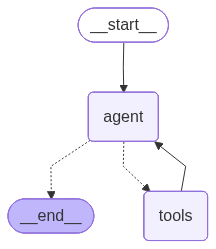

In [20]:
SearchAgent

In [18]:
tools = [nilai_farhan_tool, nilai_ratu_tool]

In [32]:
academic_agent = create_react_agent(
    name= "AcademicAgent",
    model = model,
    prompt = """
        kamu adala Agent yang berfokus pada akademik mahasiswa.
        kamu sudah terhubung ke dalam info nilai nilai mahasiswa.
        hasil output kamu hharus dilaporkan ke supervisor.
        lakukan laporan sesuai dengan seperti kamu memberikan informasi ke supervisor.
        kamu tidak boleh menjawab selain perihal mahasiswa
    """,
    tools= tools
)

C:\Users\Farhan Kamil\AppData\Local\Temp\ipykernel_17780\4039068820.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  academic_agent = create_react_agent(


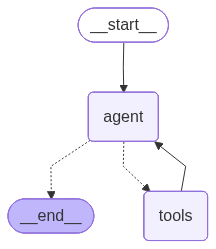

In [33]:
academic_agent

In [38]:
supervisor_agent = create_supervisor(
    supervisor_name="supervisor_akademik",
    prompt="""
        kamu adalah seorang supervisor akademik.
        kamu sudah terhubung ke agent lainnya yang berfokus pada kinerja masing masing.
        berikut adalah agent yang bisa kamu hubungi:
            AcademicAgent : Berfokus bagaimana mendapatkan informasi nilai, IPK, nomor dan informasi lainnya tentang mahasiswa,
            SearchAgent : Agent yang memiliki kemampuan untuk mencari berita terbaru.
            
        jangan hasilkan output secara sendiri, kamu adalah supervisor yang hanya memeriksa state akhir dari setiap agent.
    """,
    output_mode="full_history",
    add_handoff_back_messages= True,
    parallel_tool_calls= False,
    agents = [academic_agent, SearchAgent],
    model = model
    
)

In [39]:
app = supervisor_agent.compile()


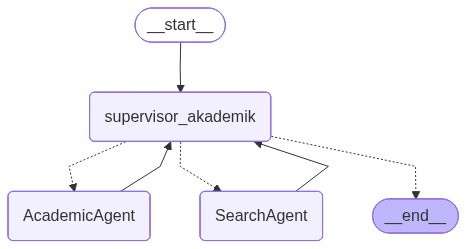

In [40]:
app

In [44]:
result = app.invoke({
    "messages" : [
        {
            "role" : "user",
            "content" : "berikan berita ai engineer terbaru ya"
        }
    ]
})

In [45]:
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

berikan berita ai engineer terbaru ya
================================== Ai Message ==================================
Name: supervisor_akademik
Tool Calls:
  transfer_to_searchagent (fc_f34aa2f7-67a5-4f4b-860b-5c6112db9bb1)
 Call ID: fc_f34aa2f7-67a5-4f4b-860b-5c6112db9bb1
  Args:
    query: latest AI engineer news
================================= Tool Message =================================
Name: transfer_to_searchagent

Successfully transferred to SearchAgent
================================== Ai Message ==================================
Name: SearchAgent
Tool Calls:
  tavily_search (fc_36dc23e1-1ba5-42fa-b17c-a1fcb2db9f6e)
 Call ID: fc_36dc23e1-1ba5-42fa-b17c-a1fcb2db9f6e
  Args:
    query: AI engineer news latest 2024
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "AI engineer news la

In [46]:
result = app.invoke({
    "messages" : [
        {
            "role" : "user",
            "content" : "bisa bantu aku carikan nilai dan ipk dari mahasiswa Farhan dan ratir dan juga berikan hasil akir perrbandingan kedua mahasiwa ini, lalu carikan di google manakah mahasiswa yang memiliki kesempatan mendaptakan beasiswa s2 di luar negeri dan berikan berita ai engineer terbaru ya"
        }
    ]
})

In [47]:
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

bisa bantu aku carikan nilai dan ipk dari mahasiswa Farhan dan ratir dan juga berikan hasil akir perrbandingan kedua mahasiwa ini, lalu carikan di google manakah mahasiswa yang memiliki kesempatan mendaptakan beasiswa s2 di luar negeri dan berikan berita ai engineer terbaru ya
================================== Ai Message ==================================
Name: supervisor_akademik
Tool Calls:
  transfer_to_academicagent (fc_cb1d6584-da0d-445f-8227-8cc6a501227b)
 Call ID: fc_cb1d6584-da0d-445f-8227-8cc6a501227b
  Args:
    : {}
================================= Tool Message =================================
Name: transfer_to_academicagent

Successfully transferred to AcademicAgent
================================== Ai Message ==================================
Name: AcademicAgent
Tool Calls:
  SikadFarhan (fc_1eb3025c-53be-4bfa-8cec-a01d6e9dc55f)
 Call ID: fc_1eb3025c-53be-4bfa-8cec-a01d6e9dc55f
  Args:
 